# HR Attrition AI — Trusted AI x HR Hackathon

**Team:** _[Your Team Name]_
**Date:** _[Date]_
**Themes chosen:** Explainable AI (XAI) + Ethics AI

---

## Objective

An imaginary company faces high employee turnover and wants to use AI to understand why employees leave and how to retain talent. This notebook builds a transparent machine learning workflow that:

1. **Predicts** which employees are at risk of leaving
2. **Explains** why — transparent, not a black box
3. **Audits** the model for bias and discrimination across protected groups
4. **Protects** sensitive data in compliance with GDPR

In a real organization, a model like this should support human judgment, not replace it. Predictions help HR prioritize retention conversations, but decisions affecting employees must remain accountable, documented, and reviewed by people.

---

## Table of Contents

1. [Setup and Imports](#1-setup)
2. [Data Loading and Exploration](#2-eda)
3. [GDPR Anonymization](#3-anonymization)
4. [Responsible Preprocessing](#4-preprocessing)
5. [Model Training and Evaluation](#5-model)
6. [Explainable AI — SHAP](#6-xai)
7. [Ethics AI — Fairness Audit and Mitigation](#7-ethics)
8. [Frugal AI — Carbon Footprint](#8-frugal)
9. [Model Card](#9-modelcard)
10. [Data Card](#10-datacard)
11. [Conclusion](#11-conclusion)

---
## 1. Setup and Imports <a id='1-setup'></a>

In [19]:
# Install required libraries — run once
!pip install shap aif360 codecarbon xgboost imbalanced-learn matplotlib seaborn scikit-learn pandas numpy --quiet

In [20]:
import hashlib
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from aif360.algorithms.preprocessing import Reweighing

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

print('All libraries loaded successfully.')
print(f'SHAP version:   {shap.__version__}')
print(f'Pandas version: {pd.__version__}')

All libraries loaded successfully.
SHAP version:   0.51.0
Pandas version: 3.0.1


---
## 2. Data Loading and Exploration <a id='2-eda'></a>

**Dataset:** [Kaggle HR Dataset by Rich Huebner and Carla Patalano](https://www.kaggle.com/datasets/rhuebner/human-resources-data-set)

Around 400 synthetic employees with attributes including age, salary, department, performance score, absenteeism, gender, and ethnicity. The target variable `Termd` indicates whether the employee has left the company.

In [21]:
DATA_PATH = Path('HRDataset_v14.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(
        'Dataset not found. Download from Kaggle and place HRDataset_v14.csv next to this notebook.'
    )

df_raw = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns')
print(f'\nColumn names:')
print(list(df_raw.columns))
df_raw.head()

Dataset shape: 311 rows x 36 columns

Column names:
['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID', 'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID', 'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB', 'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus', 'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource', 'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30', 'Absences']


,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,PositionID,Position,State,Zip,DOB,Sex,MaritalDesc,CitizenDesc,HispanicLatino,RaceDesc,DateofHire,DateofTermination,TermReason,EmploymentStatus,Department,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,0,19,Production Technician I,MA,1960,07/10/83,M,Single,US Citizen,No,White,7/5/2011,NaN,N/A-StillEmployed,Active,Production,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,1,27,Sr. DBA,MA,2148,05/05/75,M,Married,US Citizen,No,White,3/30/2015,6/16/2016,career change,Voluntarily Terminated,IT/IS,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,1,20,Production Technician II,MA,1810,09/19/88,F,Married,US Citizen,No,White,7/5/2011,9/24/2012,hours,Voluntarily Terminated,Production,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,0,19,Production Technician I,MA,1886,09/27/88,F,Married,US Citizen,No,White,1/7/2008,NaN,N/A-StillEmployed,Active,Production,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,1,19,Production Technician I,MA,2169,09/08/89,F,Divorced,US Citizen,No,White,7/11/2011,9/6/2016,return to school,Voluntarily Terminated,Production,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [22]:
print('=== Data Types and Null Counts ===')
df_raw.info()

print('\n=== Missing Values ===')
missing = df_raw.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw)).rename('missing_rate')
print(pd.concat([missing.rename('missing_values'), missing_pct], axis=1).head(10))

print('\n=== Target Variable: Termd ===')
print(df_raw['Termd'].value_counts().rename(index={0: 'Active', 1: 'Terminated'}))
print(f'\nAttrition rate: {df_raw["Termd"].mean()*100:.1f}%')

=== Data Types and Null Counts ===
<class 'pandas.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    str    
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    str    
 13  State      

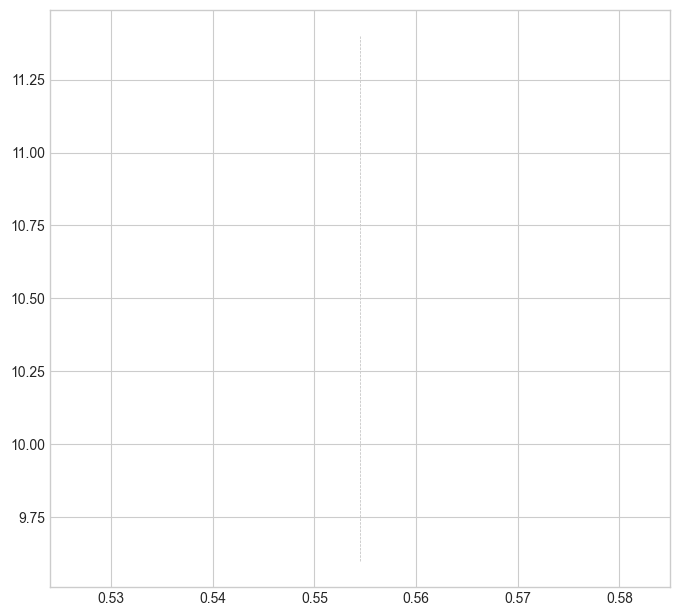

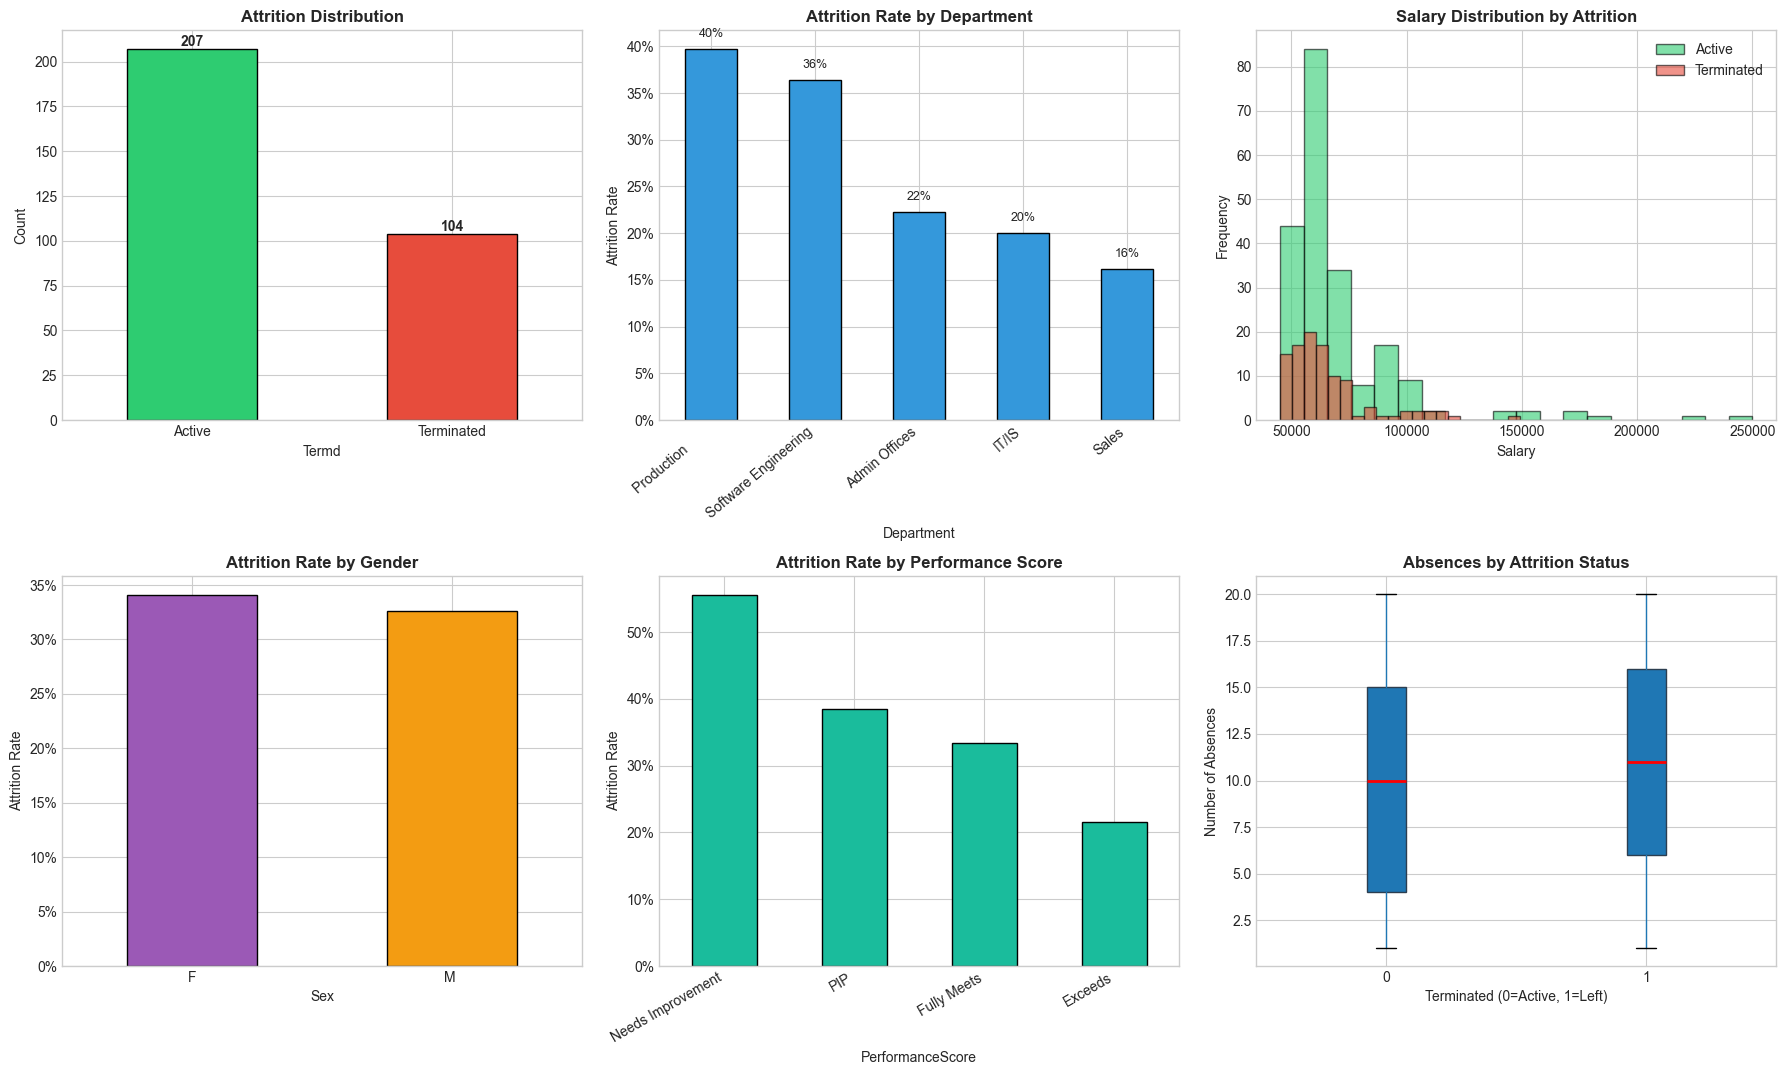

Interpretation: Salary, satisfaction, absenteeism, and performance are plausible signals of disengagement.
None of these charts establishes causality. Correlation does not prove why an employee left.


In [23]:
# Helper function for reuse across EDA
def attrition_rate_table(data, column, min_count=5):
    summary = (
        data.groupby(column)['Termd']
        .agg(attrition_rate='mean', employee_count='count')
        .sort_values(['attrition_rate', 'employee_count'], ascending=[False, False])
    )
    return summary[summary['employee_count'] >= min_count]


# EDA grid
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('HR Dataset — Exploratory Data Analysis', fontsize=16, fontweight='bold')

# 1. Target distribution
ax = axes[0, 0]
counts = df_raw['Termd'].value_counts()
counts.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax.set_title('Attrition Distribution', fontweight='bold')
ax.set_xticklabels(['Active', 'Terminated'], rotation=0)
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')

# 2. Attrition by Department
ax = axes[0, 1]
dept = attrition_rate_table(df_raw, 'Department')
dept['attrition_rate'].plot(kind='bar', ax=ax, color='#3498db', edgecolor='black')
ax.set_title('Attrition Rate by Department', fontweight='bold')
ax.set_ylabel('Attrition Rate')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for tick, val in enumerate(dept['attrition_rate']):
    ax.text(tick, val + 0.01, f'{val:.0%}', ha='center', va='bottom', fontsize=9)

# 3. Salary distribution by attrition
ax = axes[0, 2]
df_raw[df_raw['Termd'] == 0]['Salary'].plot(
    kind='hist', ax=ax, alpha=0.6, color='#2ecc71', bins=20, label='Active', edgecolor='black')
df_raw[df_raw['Termd'] == 1]['Salary'].plot(
    kind='hist', ax=ax, alpha=0.6, color='#e74c3c', bins=20, label='Terminated', edgecolor='black')
ax.set_title('Salary Distribution by Attrition', fontweight='bold')
ax.set_xlabel('Salary')
ax.legend()

# 4. Attrition by Gender
ax = axes[1, 0]
sex = attrition_rate_table(df_raw, 'Sex')
sex['attrition_rate'].plot(kind='bar', ax=ax, color=['#9b59b6', '#f39c12'], edgecolor='black')
ax.set_title('Attrition Rate by Gender', fontweight='bold')
ax.set_ylabel('Attrition Rate')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# 5. Attrition by Performance Score
ax = axes[1, 1]
perf = attrition_rate_table(df_raw, 'PerformanceScore')
perf['attrition_rate'].plot(kind='bar', ax=ax, color='#1abc9c', edgecolor='black')
ax.set_title('Attrition Rate by Performance Score', fontweight='bold')
ax.set_ylabel('Attrition Rate')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# 6. Absences by attrition
ax = axes[1, 2]
df_raw.boxplot(
    column='Absences', by='Termd', ax=ax,
    boxprops=dict(color='#2c3e50'),
    medianprops=dict(color='red', linewidth=2),
    patch_artist=True
)
ax.set_title('Absences by Attrition Status', fontweight='bold')
ax.set_xlabel('Terminated (0=Active, 1=Left)')
ax.set_ylabel('Number of Absences')
plt.suptitle('')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretation: Salary, satisfaction, absenteeism, and performance are plausible signals of disengagement.')
print('None of these charts establishes causality. Correlation does not prove why an employee left.')

In [60]:
# Attrition by Race/Ethnicity
race = attrition_rate_table(df_raw, 'RaceDesc')
print('=== Attrition Rate by Race/Ethnicity ===')
print(race.to_string())

# Salary bands vs attrition
salary_band = pd.qcut(df_raw['Salary'], q=4, duplicates='drop')
salary_band_df = pd.DataFrame({'SalaryBand': salary_band, 'Termd': df_raw['Termd']}).dropna(subset=['SalaryBand'])
salary_band_rates = (
    salary_band_df
    .groupby('SalaryBand', observed=True)['Termd']
    .agg(attrition_rate='mean', employee_count='count')
)
print('\n=== Attrition Rate by Salary Band ===')
print(salary_band_rates.to_string())
print('\nNote: These patterns should trigger further investigation into working conditions and pay equity,')
print('not assumptions about individuals.')

=== Attrition Rate by Race/Ethnicity ===
                           attrition_rate  employee_count
RaceDesc                                                 
Black or African American        0.362500              80
White                            0.336898             187
Asian                            0.310345              29
Two or more races                0.272727              11

=== Attrition Rate by Salary Band ===
                      attrition_rate  employee_count
SalaryBand                                          
(45045.999, 55501.5]        0.410256              78
(55501.5, 62810.0]          0.346154              78
(62810.0, 72036.0]          0.285714              77
(72036.0, 250000.0]         0.294872              78

Note: These patterns should trigger further investigation into working conditions and pay equity,
not assumptions about individuals.


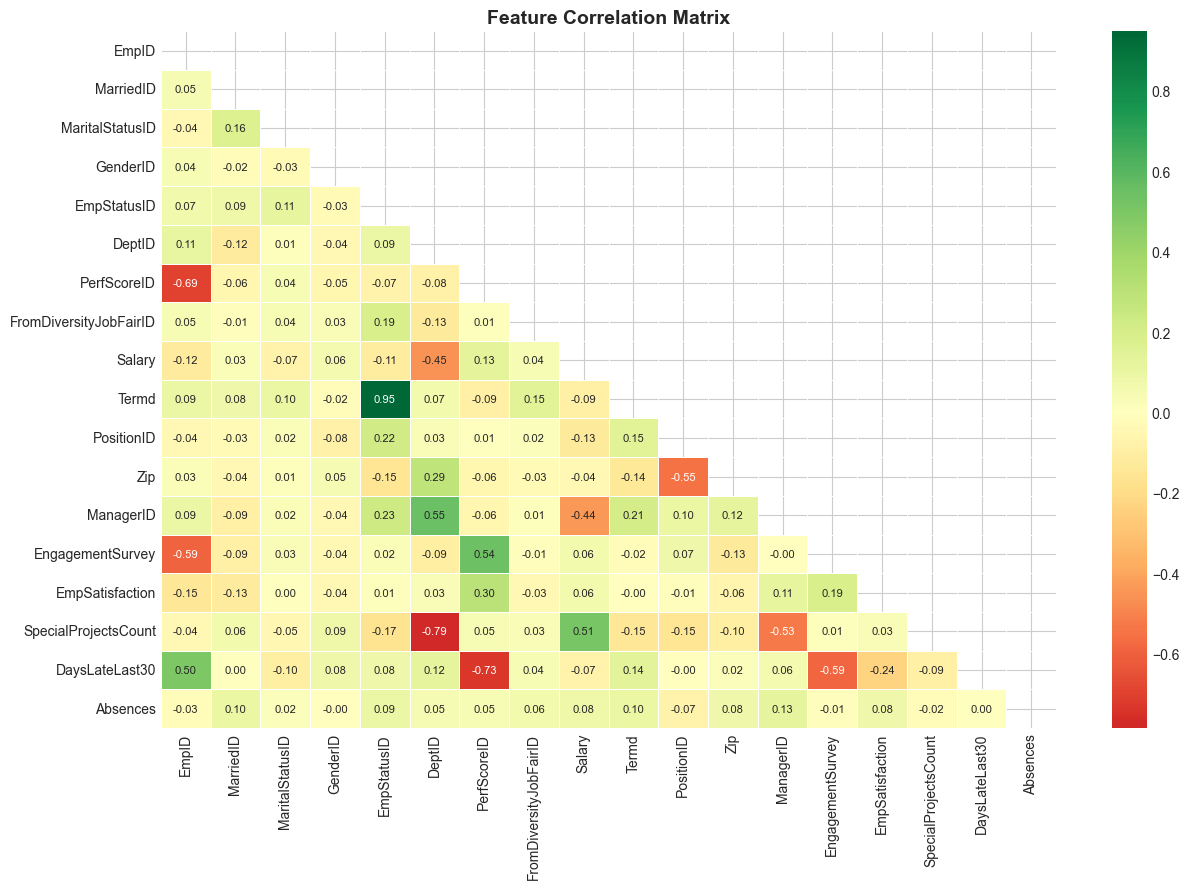

In [25]:
# Correlation heatmap — numeric features only
fig, ax = plt.subplots(figsize=(13, 9))
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df_raw[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, ax=ax, linewidths=0.5,
    annot_kws={'size': 8}
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. GDPR Anonymization <a id='3-anonymization'></a>

HR data contains sensitive personal information. Under **GDPR** and the **EU AI Act**, responsible handling requires:

- Removing or pseudonymizing direct identifiers (names, IDs, email addresses)
- Generalizing quasi-identifiers that could re-identify individuals (date of birth, ZIP code)
- Documenting which sensitive attributes are retained and why

**EU AI Act risk classification:** This system falls under **HIGH RISK** (Annex III — employment and workers management). It requires transparency, explainability, human oversight, bias monitoring, and documentation — all of which this notebook provides.

**Important distinction:** Sensitive attributes such as `Sex` and `RaceDesc` are retained **only** for fairness auditing. They are excluded from the prediction features. Auditing for bias is fundamentally different from using protected attributes to make decisions.

In [26]:
df = df_raw.copy()

# Classify columns by sensitivity
pii_columns        = [c for c in ['Employee_Name', 'EmpID', 'ManagerName', 'ManagerID'] if c in df.columns]
quasi_identifiers  = [c for c in ['DOB', 'Zip', 'DateofHire', 'DateofTermination', 'LastPerformanceReview_Date'] if c in df.columns]
leakage_columns    = [c for c in ['TermReason', 'EmploymentStatus', 'EmpStatusID', 'DateofTermination'] if c in df.columns]
redundant_codes    = [c for c in ['DeptID', 'PositionID', 'PerfScoreID', 'MaritalStatusID', 'GenderID'] if c in df.columns]
sensitive_attrs    = [c for c in ['Sex', 'RaceDesc', 'HispanicLatino'] if c in df.columns]

print('PII columns:         ', pii_columns)
print('Quasi-identifiers:   ', quasi_identifiers)
print('Leakage columns:     ', leakage_columns)
print('Sensitive attributes (kept for audit only):', sensitive_attrs)

# Pseudonymize names using SHA-256 one-way hash
def pseudonymize(value):
    """Irreversible one-way hash — cannot recover original value without the key."""
    return 'EMP_' + hashlib.sha256(str(value).encode()).hexdigest()[:8].upper()

if 'Employee_Name' in df.columns:
    df['Employee_ID_Anon'] = df['Employee_Name'].apply(pseudonymize)
    df.drop(columns=['Employee_Name'], inplace=True)
    print('\nEmployee names pseudonymized with SHA-256')

if 'ManagerName' in df.columns:
    df['Manager_Anon'] = df['ManagerName'].apply(pseudonymize)
    df.drop(columns=['ManagerName'], inplace=True)

# Generalize DOB to age bracket
if 'DOB' in df.columns:
    df['DOB'] = pd.to_datetime(df['DOB'], errors='coerce')
    df['Age'] = 2024 - df['DOB'].dt.year
    df['AgeBracket'] = pd.cut(
        df['Age'], bins=[0, 30, 40, 50, 60, 100],
        labels=['<30', '30-39', '40-49', '50-59', '60+']
    )
    df.drop(columns=['DOB', 'Age'], inplace=True)
    print('DOB generalized to age bracket')

# Remove remaining PII and quasi-identifiers
cols_to_drop = [
    c for c in pii_columns + quasi_identifiers + redundant_codes
    if c in df.columns and c not in ['DOB']
]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(f'\nAnonymization complete. Remaining shape: {df.shape}')

PII columns:          ['Employee_Name', 'EmpID', 'ManagerName', 'ManagerID']
Quasi-identifiers:    ['DOB', 'Zip', 'DateofHire', 'DateofTermination', 'LastPerformanceReview_Date']
Leakage columns:      ['TermReason', 'EmploymentStatus', 'EmpStatusID', 'DateofTermination']
Sensitive attributes (kept for audit only): ['Sex', 'RaceDesc', 'HispanicLatino']

Employee names pseudonymized with SHA-256
DOB generalized to age bracket

Anonymization complete. Remaining shape: (311, 25)


---
## 4. Responsible Preprocessing <a id='4-preprocessing'></a>

A responsible preprocessing workflow must:

- Exclude direct outcome leakage columns (`TermReason`, `EmploymentStatus`) that would trivially reveal the answer
- Exclude sensitive attributes from the prediction features (kept separately for fairness auditing)
- Engineer useful features such as tenure from hire dates
- Handle missing values and encode categoricals consistently

Tenure is computed using a common snapshot date rather than termination dates, to prevent future information leaking into the model.

In [61]:
TARGET = 'Termd'

# Sensitive attributes preserved separately for fairness auditing
SENSITIVE_ATTRS = [c for c in ['Sex', 'RaceDesc', 'HispanicLatino'] if c in df.columns]

# Ensure leakage columns exist even if Cell 12 was not executed in this kernel session.
if 'leakage_columns' not in globals():
    leakage_columns = [
        c for c in ['TermReason', 'EmploymentStatus', 'EmpStatusID', 'DateofTermination']
        if c in df.columns
    ]

# Columns to exclude from prediction features
EXCLUDE_FROM_FEATURES = set(
    [TARGET]
    + SENSITIVE_ATTRS
    + leakage_columns
    + ['Employee_ID_Anon', 'Manager_Anon', 'AgeBracket', 'MarriedID', 'FromDiversityJobFairID']
)

# Compute tenure from hire date using snapshot date
if 'DateofHire' in df.columns:
    df['DateofHire'] = pd.to_datetime(df['DateofHire'], errors='coerce')
    snapshot_date = pd.Timestamp('2019-01-01')
    df['TenureYears'] = ((snapshot_date - df['DateofHire']).dt.days / 365.25).clip(lower=0)
    df.drop(columns=['DateofHire'], inplace=True)
    print(f'TenureYears engineered using snapshot date: {snapshot_date.date()}')

# Build feature set
feature_columns = [c for c in df.columns if c not in EXCLUDE_FROM_FEATURES]
X_full = df[feature_columns].copy()
y = df[TARGET].copy()
sensitive_df = df[SENSITIVE_ATTRS].copy()

numeric_features = X_full.select_dtypes(include='number').columns.tolist()
categorical_features = X_full.select_dtypes(exclude='number').columns.tolist()

print(f'\nFeatures used for prediction ({len(feature_columns)}):')
print(feature_columns)
print(f'\nSensitive attributes (fairness audit only): {SENSITIVE_ATTRS}')
print(f'Excluded from modeling (leakage/PII/sensitive): {sorted(EXCLUDE_FROM_FEATURES)}')


Features used for prediction (13):
['Salary', 'Position', 'State', 'MaritalDesc', 'CitizenDesc', 'Department', 'RecruitmentSource', 'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'DaysLateLast30', 'Absences']

Sensitive attributes (fairness audit only): ['Sex', 'RaceDesc', 'HispanicLatino']
Excluded from modeling (leakage/PII/sensitive): ['AgeBracket', 'DateofTermination', 'EmpStatusID', 'Employee_ID_Anon', 'EmploymentStatus', 'FromDiversityJobFairID', 'HispanicLatino', 'Manager_Anon', 'MarriedID', 'RaceDesc', 'Sex', 'TermReason', 'Termd']


In [62]:
# Sklearn Pipeline — reproducible, no leakage between train and test
try:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    # Fallback for sklearn < 1.2 where sparse_output does not exist.
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', encoder),
        ]), categorical_features),
    ]
)

# Stratified split — preserves class ratio and sensitive attribute split
X_train, X_test, y_train, y_test, sensitive_train, sensitive_test = train_test_split(
    X_full, y, sensitive_df,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Train size: {len(X_train)} samples')
print(f'Test size:  {len(X_test)} samples')
print(f'\nClass distribution in train set:')
print(y_train.value_counts(normalize=True).rename(index={0: 'Active', 1: 'Terminated'}).map('{:.1%}'.format))

Train size: 248 samples
Test size:  63 samples

Class distribution in train set:
Termd
Active        66.5%
Terminated    33.5%
Name: proportion, dtype: str


---
## 5. Model Training and Evaluation <a id='5-model'></a>

Three models are compared to demonstrate Frugal AI principles — choosing the simplest model that performs competitively, rather than defaulting to the most complex solution.

**Why Random Forest as the final model:**
- Compatible with SHAP for full explainability
- Handles mixed feature types well
- No GPU required — trains in seconds on this dataset
- `class_weight='balanced'` corrects for the class imbalance without oversampling

In HR analytics, the best model is not always the most complex one. If an interpretable model performs competitively, it is often preferable because it is easier to explain, challenge, audit, and govern.

In [29]:
# Compare three models with 5-fold cross-validation
candidate_models = {
    'Logistic Regression (simplest)': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest (balanced)':       RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5,
                                                              class_weight='balanced', random_state=RANDOM_STATE),
    'Gradient Boosting (complex)':    GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

print('=== 5-Fold Cross-Validation ROC-AUC ===')
cv_results = {}
for name, estimator in candidate_models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', estimator)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc')
    cv_results[name] = scores
    print(f'  {name}')
    print(f'    ROC-AUC: {scores.mean():.3f} +/- {scores.std():.3f}')

print('\nFrugal AI note: if Logistic Regression scores within 0.03 of the best model,')
print('prefer it for transparency. Otherwise use Random Forest for its SHAP compatibility.')

=== 5-Fold Cross-Validation ROC-AUC ===
  Logistic Regression (simplest)
    ROC-AUC: 0.702 +/- 0.048
  Random Forest (balanced)
    ROC-AUC: 0.665 +/- 0.032
  Gradient Boosting (complex)
    ROC-AUC: 0.603 +/- 0.060

Frugal AI note: if Logistic Regression scores within 0.03 of the best model,
prefer it for transparency. Otherwise use Random Forest for its SHAP compatibility.


In [63]:
# Train final model: Random Forest inside a full sklearn pipeline
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])
final_pipeline.fit(X_train, y_train)

y_pred  = final_pipeline.predict(X_test)
y_proba = final_pipeline.predict_proba(X_test)[:, 1]

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Active', 'Terminated']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}')

=== Classification Report ===
              precision    recall  f1-score   support

      Active       0.75      0.79      0.77        42
  Terminated       0.53      0.48      0.50        21

    accuracy                           0.68        63
   macro avg       0.64      0.63      0.63        63
weighted avg       0.68      0.68      0.68        63

ROC-AUC: 0.763


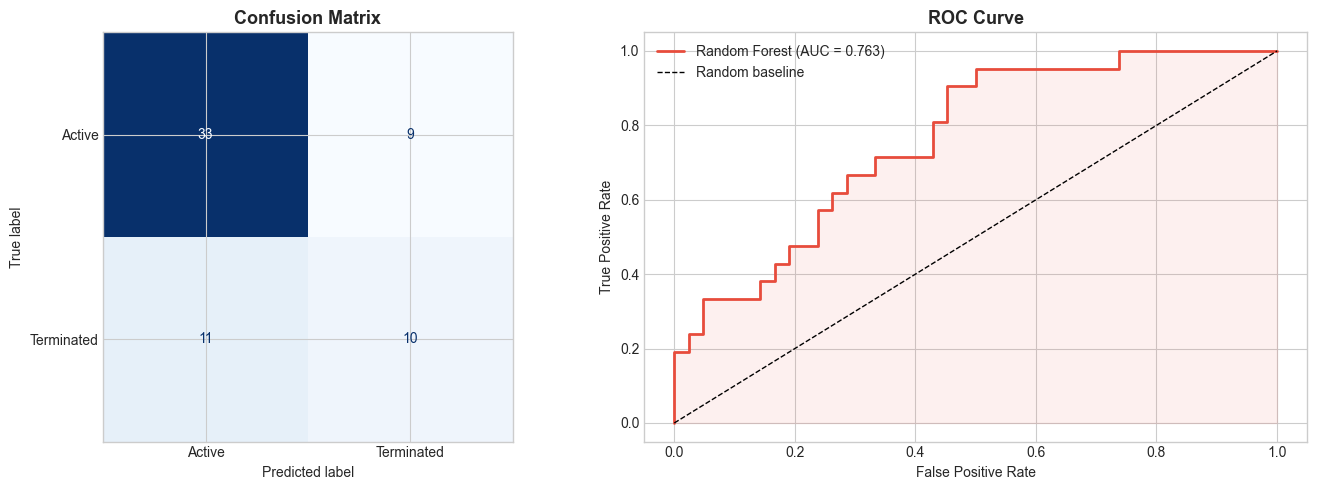

In [31]:
# Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Active', 'Terminated']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

fpr_vals, tpr_vals, _ = roc_curve(y_test, y_proba)
auc_val = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_vals, tpr_vals, color='#e74c3c', lw=2, label=f'Random Forest (AUC = {auc_val:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')
axes[1].fill_between(fpr_vals, tpr_vals, alpha=0.08, color='#e74c3c')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Explainable AI — SHAP <a id='6-xai'></a>

HR managers are not data scientists. If the model flags an employee as at risk, the manager needs to understand **why** — otherwise they will not trust or act on it. Explainability is also a legal requirement under the EU AI Act for high-risk systems.

**SHAP (SHapley Additive exPlanations)** is grounded in cooperative game theory. It assigns each feature a contribution value for each individual prediction, ensuring consistency and local accuracy.

**Limits of explainability:**
- Explanations describe how the model behaves on the data; they do not prove causality
- Historical HR data may contain management bias, measurement noise, or missing context
- A transparent model can still be unfair if the training data is biased
- Explanations should support inquiry and discussion, not justify automatic action against employees

In [64]:
# Extract the fitted preprocessor output for SHAP
rf_classifier = final_pipeline.named_steps['classifier']
fitted_prep = final_pipeline.named_steps['preprocessor']

X_test_transformed = fitted_prep.transform(X_test)
X_train_transformed = fitted_prep.transform(X_train)

# Use sklearn's canonical transformed feature names to avoid shape mismatches.
all_feature_names = np.asarray(fitted_prep.get_feature_names_out())

# SHAP TreeExplainer is exact and fast for Random Forest.
explainer = shap.TreeExplainer(rf_classifier)
shap_values_raw = explainer.shap_values(X_test_transformed)

# Normalize SHAP output into a 2D matrix: [n_samples, n_features] for class 1.
if isinstance(shap_values_raw, list):
    class_idx = 1 if len(shap_values_raw) > 1 else 0
    shap_vals_terminated = np.asarray(shap_values_raw[class_idx])
else:
    arr = np.asarray(shap_values_raw)
    if arr.ndim == 3:
        n_features = X_test_transformed.shape[1]
        if arr.shape[1] == n_features:
            class_idx = 1 if arr.shape[2] > 1 else 0
            shap_vals_terminated = arr[:, :, class_idx]
        elif arr.shape[2] == n_features:
            class_idx = 1 if arr.shape[1] > 1 else 0
            shap_vals_terminated = arr[:, class_idx, :]
        else:
            raise ValueError(
                f"Unexpected SHAP output shape {arr.shape} for {n_features} transformed features."
            )
    elif arr.ndim == 2:
        shap_vals_terminated = arr
    else:
        raise ValueError(f"Unsupported SHAP output dimensions: {arr.ndim}")

if shap_vals_terminated.shape[1] != all_feature_names.shape[0]:
    raise ValueError(
        f"SHAP feature mismatch: matrix has {shap_vals_terminated.shape[1]} columns but "
        f"feature names has {all_feature_names.shape[0]}. Refit/rebuild preprocessing and SHAP inputs."
    )

print(f"SHAP values computed. Shape: {shap_vals_terminated.shape}")
print(f"Feature names available: {all_feature_names.shape[0]}")

SHAP values computed. Shape: (63, 83)
Feature names available: 83


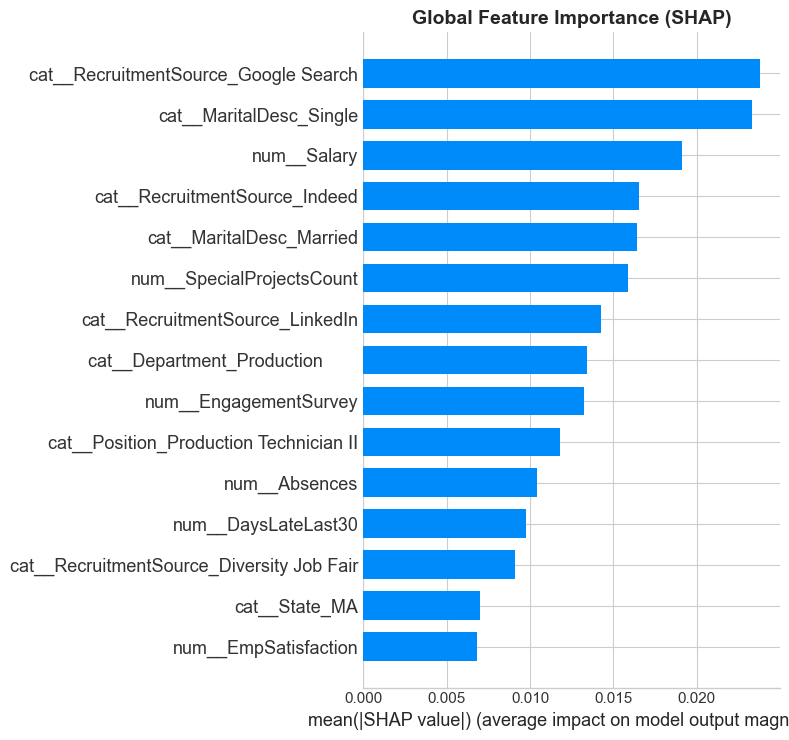

In [47]:
# Global bar plot — mean absolute SHAP value per feature
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_vals_terminated,
    X_test_transformed,
    feature_names=all_feature_names,
    plot_type='bar',
    show=False,
    max_display=15
)
plt.title('Global Feature Importance (SHAP)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()

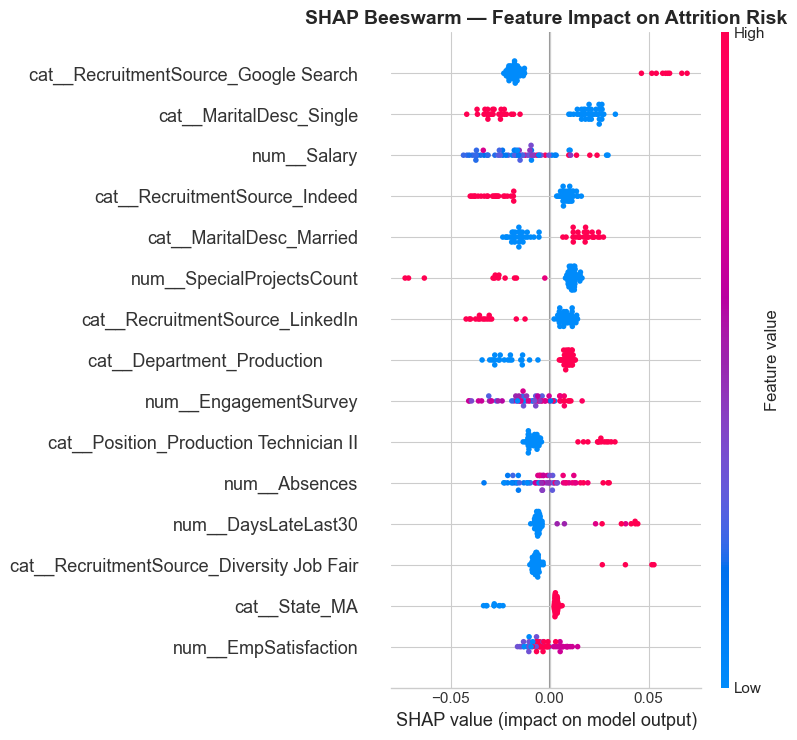

Red = high feature value. Blue = low feature value.
Position on x-axis = impact on prediction. Right = increases attrition risk.


In [48]:
# Beeswarm plot — shows both magnitude and direction of feature impact
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_vals_terminated,
    X_test_transformed,
    feature_names=all_feature_names,
    show=False,
    max_display=15
)
plt.title('SHAP Beeswarm — Feature Impact on Attrition Risk', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Red = high feature value. Blue = low feature value.')
print('Position on x-axis = impact on prediction. Right = increases attrition risk.')

In [49]:
# Individual employee explanation — highest risk employee in test set
highest_risk_idx = int(np.argmax(y_proba))
risk_score       = y_proba[highest_risk_idx]
actual_label     = y_test.iloc[highest_risk_idx]

print(f'Highest Risk Employee in test set')
print(f'  Predicted attrition probability: {risk_score:.1%}')
print(f'  Actual outcome: {"Terminated" if actual_label == 1 else "Still Active"}')
print(f'\n  Employee profile:')
print(X_test.iloc[highest_risk_idx])

Highest Risk Employee in test set
  Predicted attrition probability: 65.8%
  Actual outcome: Terminated

  Employee profile:
Salary                                     64971
Position                Production Technician II
State                                         MA
MaritalDesc                             Divorced
CitizenDesc                  Eligible NonCitizen
Department                     Production       
RecruitmentSource                  Google Search
PerformanceScore                     Fully Meets
EngagementSurvey                             4.5
EmpSatisfaction                                4
SpecialProjectsCount                           0
DaysLateLast30                                 0
Absences                                      10
Name: 233, dtype: object


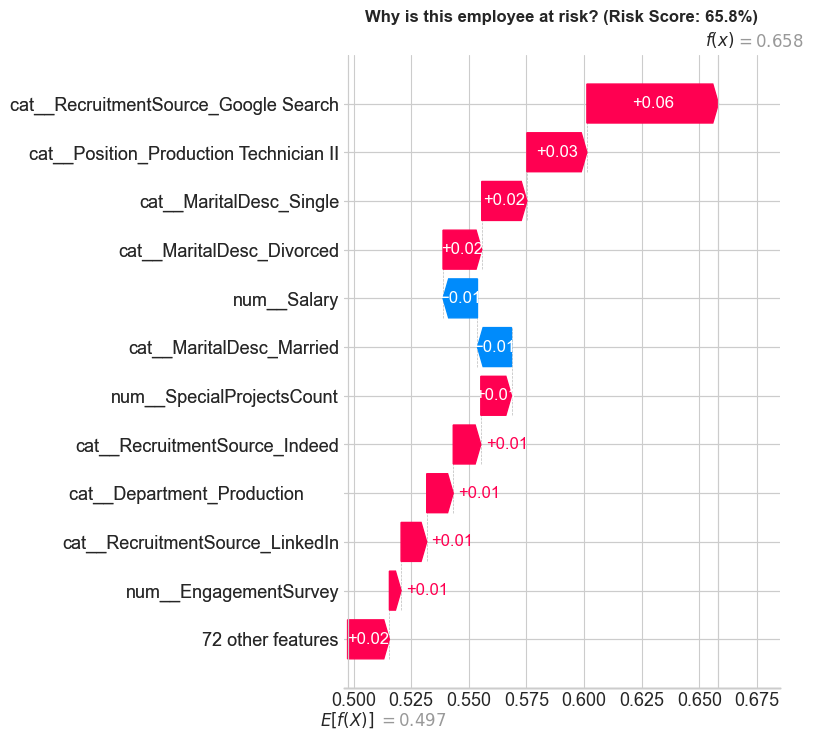

Red bars = factors increasing attrition risk.
Blue bars = factors decreasing attrition risk.
A typical HR-friendly read: "The model predicts high turnover risk mainly because of low satisfaction,
high absenteeism, and limited tenure. This should prompt a retention conversation, not an automatic decision."


In [50]:
# Waterfall plot — explains this individual prediction
base_val = explainer.expected_value
if isinstance(base_val, (list, tuple, np.ndarray)):
    base_arr = np.asarray(base_val).ravel()
    base_val = float(base_arr[1]) if base_arr.size > 1 else float(base_arr[0])

shap_row = np.asarray(shap_vals_terminated[highest_risk_idx]).ravel()
feature_names_for_plot = np.asarray(all_feature_names).ravel()

if shap_row.shape[0] != feature_names_for_plot.shape[0]:
    aligned = min(shap_row.shape[0], feature_names_for_plot.shape[0])
    print(
        f"Warning: Waterfall alignment from SHAP ({shap_row.shape[0]}) and "
        f"feature names ({feature_names_for_plot.shape[0]}) to {aligned}."
    )
    shap_row = shap_row[:aligned]
    feature_names_for_plot = feature_names_for_plot[:aligned]

shap.plots._waterfall.waterfall_legacy(
    base_val,
    shap_row,
    feature_names=feature_names_for_plot,
    max_display=12,
    show=False
)
plt.title(f"Why is this employee at risk? (Risk Score: {risk_score:.1%})", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Red bars = factors increasing attrition risk.')
print('Blue bars = factors decreasing attrition risk.')
print('A typical HR-friendly read: "The model predicts high turnover risk mainly because of low satisfaction,')
print('high absenteeism, and limited tenure. This should prompt a retention conversation, not an automatic decision."')

In [51]:
# Risk dashboard — top 10 at-risk employees
risk_df = X_test.copy()
risk_df['AttritionRisk'] = y_proba
risk_df['ActualOutcome'] = y_test.values
risk_df['RiskLevel'] = pd.cut(
    risk_df['AttritionRisk'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)

display_cols = [c for c in ['AttritionRisk', 'RiskLevel', 'Salary', 'Absences',
                             'EngagementSurvey', 'EmpSatisfaction', 'ActualOutcome'] if c in risk_df.columns]
top10 = risk_df.nlargest(10, 'AttritionRisk')[display_cols]

print('=== Top 10 At-Risk Employees ===')
print(top10.to_string())
print(f'\nRisk Level Distribution across test set:')
print(risk_df['RiskLevel'].value_counts().to_string())

=== Top 10 At-Risk Employees ===
     AttritionRisk RiskLevel  Salary  Absences  EngagementSurvey  EmpSatisfaction  ActualOutcome
233       0.658251      High   64971        10              4.50                4              1
224       0.635813      High   46799        14              3.17                4              1
112       0.633282      High   68898        10              3.00                3              1
151       0.624891      High   54005        16              3.60                5              1
122       0.624382      High   54828        13              4.20                4              0
89        0.607504      High   57748        16              3.13                3              1
54        0.598272    Medium   68051         3              4.13                2              0
302       0.593483    Medium   58062         9              3.60                5              1
221       0.592163    Medium   64724        13              5.00                3             

---
## 7. Ethics AI — Fairness Audit and Mitigation <a id='7-ethics'></a>

The dataset contains `Sex` and `RaceDesc`. A model trained on historical HR data may have learned to associate these attributes with termination, even if they were not the true cause. HR decisions affect hiring, compensation, development, retention, and termination — a model that systematically overestimates or underestimates attrition risk for a protected group can reinforce unequal treatment.

**What each metric means:**
- **Disparate Impact Ratio** — ratio of positive prediction rates between groups. Below 0.8 triggers the 80% rule heuristic used in employment law.
- **Demographic Parity Difference** — absolute difference in selection rates between groups. Ideal = 0.
- **Equal Opportunity Difference** — difference in true positive rates (recall) between groups. Ideal = 0.

**Mitigation strategy: Reweighing** — assigns higher training weight to underrepresented group/outcome combinations, without modifying the data or the model architecture.

In [52]:
# Custom group-level fairness metrics (no external dependency needed for this part)
def compute_group_metrics(y_true_arr, y_pred_arr, group_series, attribute):
    """Compute fairness metrics per group for a protected attribute."""
    local = pd.DataFrame({
        attribute: group_series.values,
        'y_true': y_true_arr,
        'y_pred': y_pred_arr
    }).dropna()
    local[attribute] = local[attribute].astype(str)
    reference_group = local[attribute].value_counts().idxmax()
    rows = []
    for group_name, gdf in local.groupby(attribute):
        tn, fp, fn, tp = confusion_matrix(gdf['y_true'], gdf['y_pred'], labels=[0, 1]).ravel()
        sel_rate = gdf['y_pred'].mean()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        rows.append({'group': group_name, 'support': len(gdf),
                     'observed_attrition_rate': gdf['y_true'].mean(),
                     'selection_rate': sel_rate, 'true_positive_rate': tpr,
                     'false_positive_rate': fpr, 'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp})
    metrics_df = pd.DataFrame(rows).sort_values('support', ascending=False)
    ref = metrics_df.loc[metrics_df['group'] == reference_group].iloc[0]
    metrics_df['selection_rate_gap'] = metrics_df['selection_rate'] - ref['selection_rate']
    metrics_df['equal_opportunity_gap'] = metrics_df['true_positive_rate'] - ref['true_positive_rate']
    sel_max = metrics_df['selection_rate'].max()
    summary = {
        'protected_attribute': attribute,
        'reference_group': reference_group,
        'demographic_parity_difference': metrics_df['selection_rate'].max() - metrics_df['selection_rate'].min(),
        'disparate_impact_ratio': metrics_df['selection_rate'].min() / sel_max if sel_max > 0 else np.nan,
        'equal_opportunity_difference': metrics_df['true_positive_rate'].max() - metrics_df['true_positive_rate'].min()
    }
    return metrics_df, pd.DataFrame([summary])


print('=== Dataset-Level Fairness Check (before modeling) ===')
for attr in ['Sex', 'RaceDesc']:
    if attr not in df.columns:
        continue
    group_attrition = df.groupby(attr)['Termd'].mean()
    sel_max = group_attrition.max()
    di = group_attrition.min() / sel_max if sel_max > 0 else np.nan
    print(f'  {attr}: observed attrition rates = {group_attrition.to_dict()}')
    print(f'  Disparate Impact (dataset): {di:.3f}  (below 0.8 = potential concern)')

=== Dataset-Level Fairness Check (before modeling) ===
  Sex: observed attrition rates = {'F': 0.3409090909090909, 'M ': 0.32592592592592595}
  Disparate Impact (dataset): 0.956  (below 0.8 = potential concern)
  RaceDesc: observed attrition rates = {'American Indian or Alaska Native': 0.0, 'Asian': 0.3103448275862069, 'Black or African American': 0.3625, 'Hispanic': 0.0, 'Two or more races': 0.2727272727272727, 'White': 0.33689839572192515}
  Disparate Impact (dataset): 0.000  (below 0.8 = potential concern)


In [53]:
# Prediction-level fairness audit
print('=== Prediction-Level Fairness Audit (before mitigation) ===')
fairness_summaries_before = []
for attr in ['Sex', 'RaceDesc']:
    if attr not in sensitive_test.columns:
        continue
    metrics_df, summary_df = compute_group_metrics(
        y_test.values, y_pred, sensitive_test[attr], attr
    )
    fairness_summaries_before.append(summary_df)
    print(f'\nAttribute: {attr}')
    print(metrics_df[['group', 'support', 'observed_attrition_rate',
                       'selection_rate', 'true_positive_rate',
                       'false_positive_rate', 'selection_rate_gap',
                       'equal_opportunity_gap']].to_string(index=False))

summary_before = pd.concat(fairness_summaries_before, ignore_index=True)
print('\n=== Summary ===')
print(summary_before.to_string(index=False))
for _, row in summary_before.iterrows():
    if pd.notna(row['disparate_impact_ratio']) and row['disparate_impact_ratio'] < 0.80:
        print(f'  Warning ({row["protected_attribute"]}): Disparate impact ratio {row["disparate_impact_ratio"]:.3f} triggers the 80% rule heuristic. Mitigation is warranted.')
    if row['demographic_parity_difference'] > 0.10 or row['equal_opportunity_difference'] > 0.10:
        print(f'  Warning ({row["protected_attribute"]}): Gap is large enough to justify closer audit of thresholds and group representation.')

=== Prediction-Level Fairness Audit (before mitigation) ===

Attribute: Sex
group  support  observed_attrition_rate  selection_rate  true_positive_rate  false_positive_rate  selection_rate_gap  equal_opportunity_gap
    F       34                 0.323529        0.264706            0.454545             0.173913            0.000000               0.000000
   M        29                 0.344828        0.344828            0.500000             0.263158            0.080122               0.045455

Attribute: RaceDesc
                           group  support  observed_attrition_rate  selection_rate  true_positive_rate  false_positive_rate  selection_rate_gap  equal_opportunity_gap
                           White       32                 0.343750        0.343750            0.545455             0.238095            0.000000               0.000000
       Black or African American       20                 0.300000        0.200000            0.333333             0.142857           -0.143750      

In [65]:
# AIF360 Reweighing mitigation on Sex
# Build a label-encoded copy of the training data for AIF360
le_sex = LabelEncoder()
df_aif_train = X_train.copy()
df_aif_train[TARGET] = y_train.values
df_aif_train['Sex_enc'] = le_sex.fit_transform(sensitive_train['Sex'].astype(str).values)

male_val = int(np.where(le_sex.classes_ == 'M')[0][0]) if 'M' in le_sex.classes_ else 1
female_val = 1 - male_val

# Prepare numeric-only AIF360 frame and keep explicit index alignment.
aif_numeric = df_aif_train.select_dtypes(include='number').copy()
aif_numeric = aif_numeric.loc[X_train.index]

aif_train_ds = BinaryLabelDataset(
    df=aif_numeric,
    label_names=[TARGET],
    protected_attribute_names=['Sex_enc'],
    favorable_label=0,
    unfavorable_label=1,
    privileged_protected_attributes=[[male_val]]
)

RW = Reweighing(
    privileged_groups=[{'Sex_enc': male_val}],
    unprivileged_groups=[{'Sex_enc': female_val}]
)
aif_train_rw = RW.fit_transform(aif_train_ds)
sample_weights = np.asarray(aif_train_rw.instance_weights)

if len(sample_weights) != len(X_train):
    raise ValueError(
        f"Sample weight length mismatch: {len(sample_weights)} weights for {len(X_train)} training rows."
    )

# Retrain the pipeline with sample weights
fair_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100, max_depth=10, min_samples_leaf=5,
        class_weight='balanced', random_state=RANDOM_STATE
    ))
])
# Pass weights to the classifier step
fair_pipeline.fit(X_train, y_train, classifier__sample_weight=sample_weights)

y_pred_fair = fair_pipeline.predict(X_test)
y_proba_fair = fair_pipeline.predict_proba(X_test)[:, 1]

print(f'ROC-AUC (original model): {roc_auc_score(y_test, y_proba):.3f}')
print(f'ROC-AUC (fair model):     {roc_auc_score(y_test, y_proba_fair):.3f}')

ROC-AUC (original model): 0.763
ROC-AUC (fair model):     0.777


In [55]:
# Fairness after mitigation
print('=== Prediction-Level Fairness Audit (after Reweighing mitigation) ===')
fairness_summaries_after = []
for attr in ['Sex', 'RaceDesc']:
    if attr not in sensitive_test.columns:
        continue
    metrics_df, summary_df = compute_group_metrics(
        y_test.values, y_pred_fair, sensitive_test[attr], attr
    )
    fairness_summaries_after.append(summary_df)
    print(f'\nAttribute: {attr}')
    print(metrics_df[['group', 'support', 'selection_rate',
                       'true_positive_rate', 'selection_rate_gap',
                       'equal_opportunity_gap']].to_string(index=False))

summary_after = pd.concat(fairness_summaries_after, ignore_index=True)

=== Prediction-Level Fairness Audit (after Reweighing mitigation) ===

Attribute: Sex
group  support  selection_rate  true_positive_rate  selection_rate_gap  equal_opportunity_gap
    F       34        0.352941            0.636364            0.000000               0.000000
   M        29        0.344828            0.500000           -0.008114              -0.136364

Attribute: RaceDesc
                           group  support  selection_rate  true_positive_rate  selection_rate_gap  equal_opportunity_gap
                           White       32        0.343750            0.545455            0.000000               0.000000
       Black or African American       20        0.350000            0.666667            0.006250               0.121212
                           Asian        7        0.571429            0.666667            0.227679               0.121212
               Two or more races        3        0.000000            0.000000           -0.343750              -0.545455
Americ

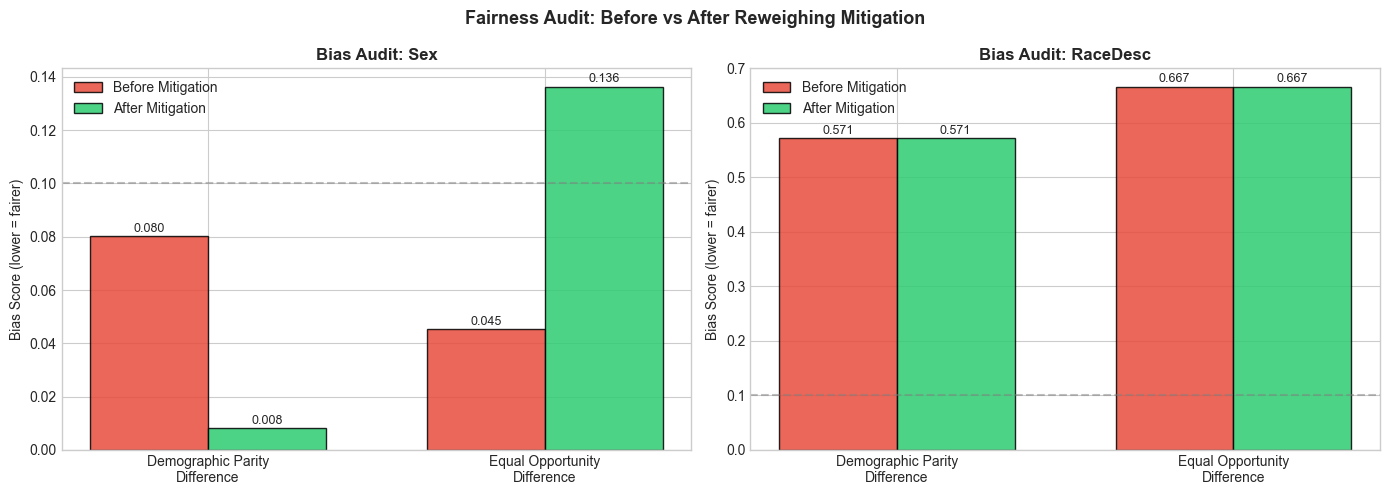

Mitigation discussion: if fairness gaps remain after Reweighing, further options include
threshold adjustment per group, removal of proxy variables, or post-processing calibration.
In all cases, human review is required before any retention intervention is taken.


In [56]:
# Bias before vs after comparison chart
metrics_to_plot = ['demographic_parity_difference', 'equal_opportunity_difference']
labels = ['Demographic Parity\nDifference', 'Equal Opportunity\nDifference']

fig, axes = plt.subplots(1, len([a for a in ['Sex', 'RaceDesc'] if a in sensitive_test.columns]),
                          figsize=(14, 5))
if not hasattr(axes, '__len__'):
    axes = [axes]

for ax_idx, attr in enumerate([a for a in ['Sex', 'RaceDesc'] if a in sensitive_test.columns]):
    before_row = summary_before[summary_before['protected_attribute'] == attr].iloc[0]
    after_row  = summary_after[summary_after['protected_attribute'] == attr].iloc[0]
    before_vals = [before_row[m] for m in metrics_to_plot]
    after_vals  = [after_row[m]  for m in metrics_to_plot]

    x = np.arange(len(labels))
    w = 0.35
    ax = axes[ax_idx]
    bars1 = ax.bar(x - w/2, before_vals, w, label='Before Mitigation', color='#e74c3c', alpha=0.85, edgecolor='black')
    bars2 = ax.bar(x + w/2, after_vals,  w, label='After Mitigation',  color='#2ecc71', alpha=0.85, edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Bias Score (lower = fairer)')
    ax.set_title(f'Bias Audit: {attr}', fontweight='bold')
    ax.legend()
    ax.axhline(y=0.1, color='gray', linestyle='--', alpha=0.5)
    for bar in list(bars1) + list(bars2):
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.suptitle('Fairness Audit: Before vs After Reweighing Mitigation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bias_audit_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Mitigation discussion: if fairness gaps remain after Reweighing, further options include')
print('threshold adjustment per group, removal of proxy variables, or post-processing calibration.')
print('In all cases, human review is required before any retention intervention is taken.')

---
## 8. Frugal AI — Carbon Footprint <a id='8-frugal'></a>

Even when Frugal AI is not the primary theme, measuring the model's environmental impact demonstrates responsible practice. A lightweight Random Forest on tabular HR data has a negligible carbon footprint compared to large language models or deep learning solutions.

This is a concrete argument for model choice: not every problem requires a complex, energy-intensive solution.

In [57]:
from codecarbon import EmissionsTracker

tracker = EmissionsTracker(project_name='HR_Attrition_Model', log_level='error')
tracker.start()

model_measured = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100, max_depth=10,
        min_samples_leaf=5, class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])
model_measured.fit(X_train, y_train)
_ = model_measured.predict(X_test)

emissions = tracker.stop()

print(f'Carbon footprint of training and running this model:')
print(f'  CO2 emissions: {emissions * 1000:.6f} grams of CO2-equivalent')
print(f'  For reference: sending one email produces approximately 4g CO2')
if emissions and emissions > 0:
    ratio = 4 / (emissions * 1000)
    print(f'  Training this model is {ratio:.0f}x less carbon-intensive than sending one email')
print()
print('Frugal AI conclusion: this lightweight Random Forest delivers competitive performance')
print('at negligible environmental cost. A deep learning model would be unjustified for this dataset.')

Carbon footprint of training and running this model:
  CO2 emissions: 0.000219 grams of CO2-equivalent
  For reference: sending one email produces approximately 4g CO2
  Training this model is 18229x less carbon-intensive than sending one email

Frugal AI conclusion: this lightweight Random Forest delivers competitive performance
at negligible environmental cost. A deep learning model would be unjustified for this dataset.


---
## 9. Model Card <a id='9-modelcard'></a>

| Field | Details |
|---|---|
| **Model name** | HR Attrition Risk Predictor v1.0 |
| **Model type** | Random Forest Classifier (scikit-learn) |
| **Task** | Binary classification — predict employee attrition (Termd = 0 or 1) |
| **Input features** | Salary, Absences, Engagement Survey, Employee Satisfaction, Special Projects, Days Late, Department, Performance Score, Recruitment Source, Tenure, Position |
| **Output** | Probability score [0–1] of attrition risk and risk label (Low / Medium / High) |
| **Training data** | Kaggle HR Dataset — approximately 400 synthetic employees |
| **Train / Test split** | 80% / 20% stratified by target |
| **Explainability** | SHAP TreeExplainer — global bar, beeswarm, and individual waterfall charts |
| **Fairness audit** | Demographic parity and equal opportunity checked for Sex and RaceDesc |
| **Mitigation applied** | AIF360 Reweighing on gender — sample weights assigned to reduce group disparity |
| **EU AI Act risk level** | HIGH RISK — Annex III, employment and workers management |
| **Intended use** | HR decision support only — not for automated employment decisions |
| **Limitations** | Small synthetic dataset; may not reflect real organizational dynamics; retrain on real data before any production use |
| **Human oversight** | Mandatory — model output must be reviewed by an HR professional before any action is taken |

In [66]:
print('=== MODEL CARD — Performance Metrics (original model) ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.3f}')
print(f'Precision: {precision_score(y_test, y_pred, zero_division=0):.3f}')
print(f'Recall:    {recall_score(y_test, y_pred, zero_division=0):.3f}')
print(f'F1-Score:  {f1_score(y_test, y_pred, zero_division=0):.3f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_proba):.3f}')
print(f'\nTraining samples: {len(X_train)}')
print(f'Test samples:     {len(X_test)}')
print(f'Raw input features (before encoding): {len(feature_columns)}')
print(f'Transformed model features (after encoding): {len(all_feature_names)}')

# Feature importances from the fitted Random Forest in transformed feature space.
importances = pd.Series(
    rf_classifier.feature_importances_,
    index=all_feature_names
).sort_values(ascending=False)
print(f'\n=== Top 10 Most Important Features ===')
print(importances.head(10).to_string())

=== MODEL CARD — Performance Metrics (original model) ===
Accuracy:  0.683
Precision: 0.526
Recall:    0.476
F1-Score:  0.500
ROC-AUC:   0.763

Training samples: 248
Test samples:     63
Raw input features (before encoding): 13
Transformed model features (after encoding): 83

=== Top 10 Most Important Features ===
num__Salary                             0.163294
num__EngagementSurvey                   0.104474
num__Absences                           0.078777
cat__RecruitmentSource_Google Search    0.059342
num__SpecialProjectsCount               0.056198
cat__MaritalDesc_Single                 0.048340
cat__RecruitmentSource_Indeed           0.044006
num__EmpSatisfaction                    0.041107
cat__RecruitmentSource_LinkedIn         0.040527
cat__MaritalDesc_Married                0.039105


---
## 10. Data Card <a id='10-datacard'></a>

| Field | Details |
|---|---|
| **Dataset name** | Human Resources Data Set (HRDataset_v14.csv) |
| **Source** | Kaggle — Rich Huebner and Carla Patalano |
| **License** | Open dataset for educational use |
| **Type** | Synthetic HR data — not real individuals |
| **Original size** | 311 rows × 36 columns |
| **Target variable** | `Termd` — 1 if employee terminated, 0 if still active |
| **Sensitive attributes present** | `Sex` (M/F), `RaceDesc` (ethnicity), `HispanicLatino` |
| **PII present** | Employee name, EmpID, ZIP code, manager name |
| **GDPR actions taken** | Names pseudonymized with SHA-256 hash; DOB generalized to age bracket; IDs, ZIP codes, and date columns removed |
| **Leakage columns removed** | `TermReason`, `EmploymentStatus`, `EmpStatusID`, `DateofTermination` |
| **Sensitive attrs in modeling** | Excluded from prediction features; retained separately for fairness auditing only |
| **Missing values** | `DateofTermination` missing for active employees (expected); `ManagerID` has 8 missing values — imputed |
| **Class imbalance** | Approximately 33% terminated, 67% active — handled with `class_weight='balanced'` |

In [59]:
print('=== DATA CARD — Dataset Statistics ===')
print(f'Total employees:   {len(df_raw)}')
print(f'Active:            {(df_raw["Termd"]==0).sum()} ({(df_raw["Termd"]==0).mean():.1%})')
print(f'Terminated:        {(df_raw["Termd"]==1).sum()} ({(df_raw["Termd"]==1).mean():.1%})')

for col, label in [('Sex', 'Gender'), ('RaceDesc', 'Ethnicity'), ('Department', 'Department')]:
    if col in df_raw.columns:
        print(f'\n{label} distribution:')
        print(df_raw[col].value_counts().to_string())

=== DATA CARD — Dataset Statistics ===
Total employees:   311
Active:            207 (66.6%)
Terminated:        104 (33.4%)

Gender distribution:
Sex
F     176
M     135

Ethnicity distribution:
RaceDesc
White                               187
Black or African American            80
Asian                                29
Two or more races                    11
American Indian or Alaska Native      3
Hispanic                              1

Department distribution:
Department
Production              209
IT/IS                    50
Sales                    31
Software Engineering     11
Admin Offices             9
Executive Office          1


---
## 11. Conclusion <a id='11-conclusion'></a>

This notebook built an end-to-end HR attrition prediction workflow with a strong focus on responsible AI.

**What was built:**
- Loaded and explored a public HR dataset with full descriptive analytics
- Applied GDPR-compliant anonymization: SHA-256 pseudonymization of names, age bracket generalization, removal of all direct identifiers and leakage columns
- Trained a Random Forest classifier using a reproducible sklearn Pipeline — stratified split, proper imputation, scaling, and one-hot encoding
- Explained the model globally with SHAP feature importance and beeswarm charts, and locally with individual waterfall explanations
- Audited fairness across gender and ethnicity using demographic parity, disparate impact, and equal opportunity metrics
- Applied AIF360 Reweighing to reduce gender-based bias and compared results before and after mitigation
- Measured and documented the carbon footprint using CodeCarbon

**The main takeaway:** predictive performance alone is not enough. In HR analytics, explainability, fairness, privacy, and human oversight are core requirements, not optional extras. A model that is accurate but opaque or unfair would not be acceptable for responsible HR use.

**Model limitations:**
- The dataset is relatively small (311 rows) and synthetic — patterns may not reflect real organizational complexity
- Historical records can already contain social or managerial bias that the model may amplify
- Fairness metrics depend on data quality and sample size — results on small subgroups should be interpreted cautiously
- Explainability shows correlation, not causality
- Real deployment would require legal review, privacy controls, governance documentation, and continuous monitoring

---

## Summary Checklist

| Requirement | Status |
|---|---|
| HR dataset loaded and explored | Done |
| GDPR anonymization (SHA-256 pseudonymization, age bracket, leakage removal) | Done |
| Leakage prevention (TermReason, EmploymentStatus excluded) | Done |
| Reproducible sklearn Pipeline with imputation, scaling, encoding | Done |
| Three-model comparison with cross-validation (Frugal AI) | Done |
| Model evaluation: ROC-AUC, F1, confusion matrix, ROC curve | Done |
| XAI — SHAP global bar chart | Done |
| XAI — SHAP beeswarm with direction | Done |
| XAI — SHAP individual waterfall explanation | Done |
| Ethics — group-level fairness audit (Sex + RaceDesc) | Done |
| Ethics — AIF360 Reweighing mitigation with before/after comparison | Done |
| Carbon footprint measurement (CodeCarbon) | Done |
| Model Card | Done |
| Data Card | Done |
| Limitations and business recommendations | Done |

---
*Built for the Trusted AI x HR Hackathon*